# Medical Insurance Cost Prediction (Regression)

## Introduction

This dataset is commonly sourced from public repositories such as Kaggle and contains information about individuals' demographics and health-related attributes. The objective is to predict medical insurance charges using supervised learning (regression).

### Purpose
This dataset is used to model and understand how factors such as age, BMI, smoking status, and region affect insurance costs. It is relevant for risk assessment, pricing strategies, and customer segmentation in the insurance industry.

### Limitations
- Relatively small dataset (~2700 rows)
- Limited number of predictors
- Potential bias (e.g., underrepresentation of populations)

### Justification
This dataset is well suited for regression tasks due to a continuous target variable (charges) and a mix of categorical and numerical predictors.


## Setup and Data Loading

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/TABxSAID/Datasets/refs/heads/master/medical_insurance.csv')

# Display basic info
print("Dataset shape:", df.shape)
df.head()

# Set Seaborn theme with HUSL palette
sns.set_theme(style="whitegrid", palette="husl")



Dataset shape: (2772, 7)


## Milestone 1: Data Understanding and Quality Assessment

### 1) Data Types Identification

In [ ]:
# Data types
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
# Variable classification
print("""
Variable Classification:
- age          : continuous (integer)
- sex          : categorical nominal (male/female)
- bmi          : continuous (float)
- children     : discrete (can be treated as numeric)
- smoker       : categorical nominal (yes/no)
- region       : categorical nominal (4 regions)
- charges      : continuous (target)
""")


Variable Classification:
- age          : continuous (integer)
- sex          : categorical nominal (male/female)
- bmi          : continuous (float)
- children     : discrete (can be treated as numeric)
- smoker       : categorical nominal (yes/no)
- region       : categorical nominal (4 regions)
- charges      : continuous (target)



### 2) Data Quality Assessment

We check for missing values, duplicates, outliers, and inconsistent entries.

In [ ]:
# Missing values
missing = df.isnull().sum()
print("Missing values per column:\n", missing)
if missing.sum() == 0:
    print("\n No missing values found.")
else:
    print("\n Missing values present. Consider imputation.")

Missing values per column:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

 No missing values found.


In [ ]:
# Duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print("\nFirst few duplicates:")
    print(df[df.duplicated(keep=False)].head())
    # Remove duplicates
    df = df.drop_duplicates()
    print(f"\n Duplicates removed. New shape: {df.shape}")
else:
    print("\n No duplicate rows found.")

Number of duplicate rows: 1435

First few duplicates:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

 Duplicates removed. New shape: (1337, 7)


age: 0 outliers
bmi: 9 outliers
children: 0 outliers
charges: 139 outliers


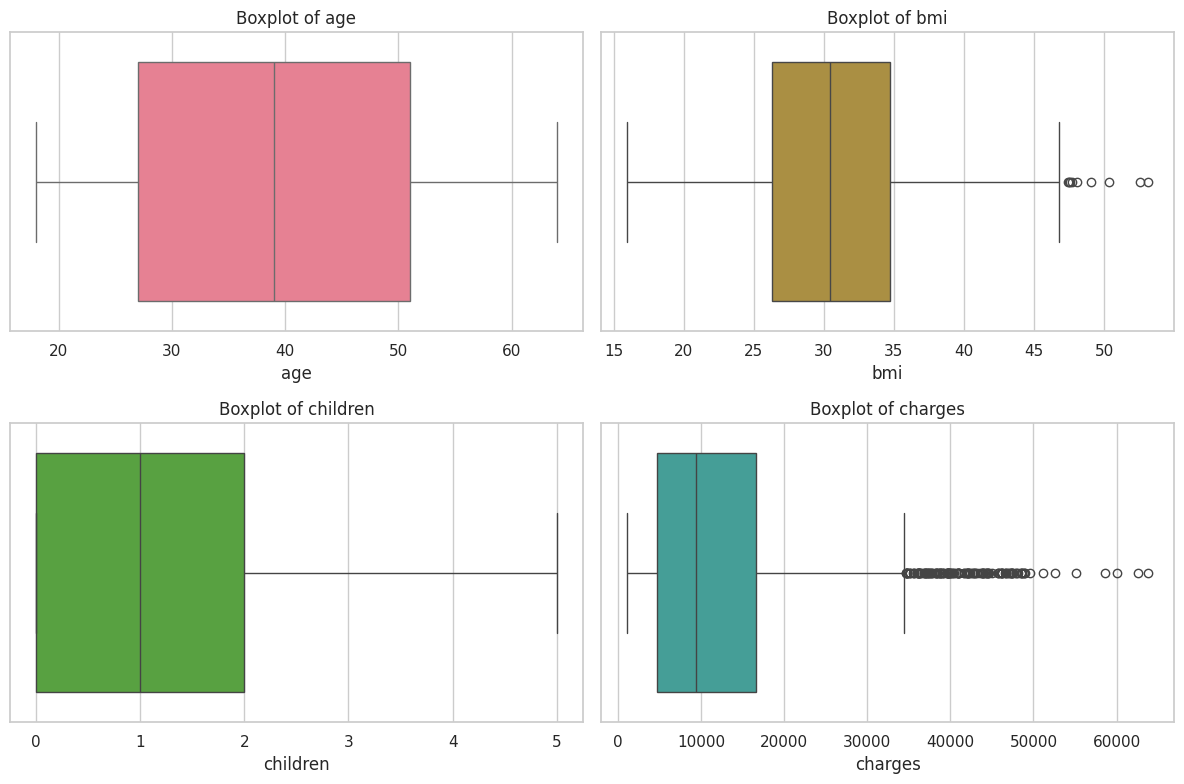

In [ ]:
# Outlier detection using IQR method
numeric_cols = ['age', 'bmi', 'children', 'charges']
outlier_counts = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_counts[col] = len(outliers)
    print(f"{col}: {len(outliers)} outliers")

# Visual inspection
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(numeric_cols):
    ax = axes[i//2, i%2]
    sns.boxplot(x=df[col], ax=ax, color=sns.color_palette("husl")[i])
    ax.set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

**Observation:** charges have many high values (true for high-risk individuals).

**Note:** we keep outliers but will later apply log transformation to reduce skewness.

In [ ]:
# Check categorical values for consistency
cat_cols = ['sex', 'smoker', 'region']
for col in cat_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].value_counts())


Unique values in sex:
sex
male      675
female    662
Name: count, dtype: int64

Unique values in smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64

Unique values in region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


**Data Quality Summary**
- No missing values.
- Duplicates removed.
- Outliers exist but are plausible; we will keep them.
- Categorical values are consistent.

## Milestone 2: Exploratory Data Analysis and Preprocessing

### 1) Exploratory Data Analysis (EDA)

We compute summary statistics and generate visualizations.

In [ ]:
# Summary statistics for numerical columns
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


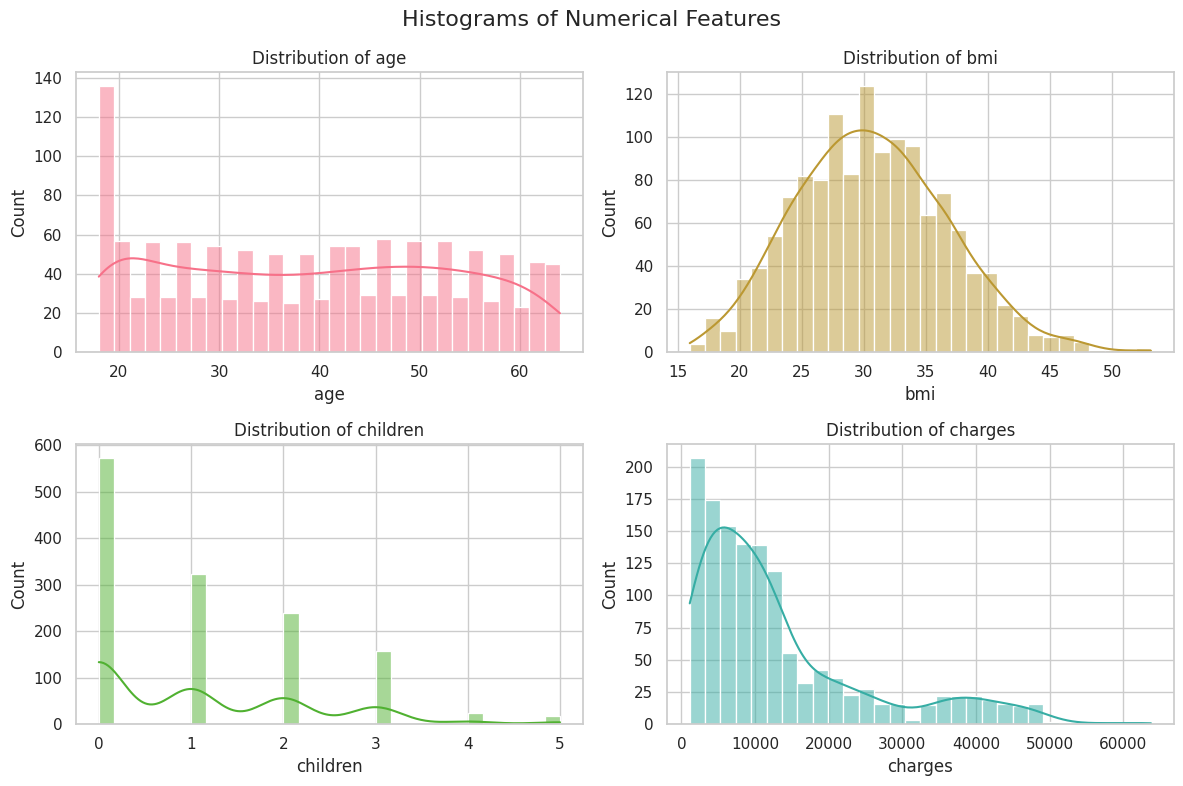

In [ ]:
# Histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(['age', 'bmi', 'children', 'charges']):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i],
                 color=sns.color_palette("husl")[i])
    axes[i].set_title(f'Distribution of {col}')

plt.suptitle('Histograms of Numerical Features', size=16)
plt.tight_layout()
plt.show()

**Observation:** charges is heavily right-skewed, therefore a log transformation recommended.

/tmp/ipykernel_10547/3083257258.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='charges', data=df,
/tmp/ipykernel_10547/3083257258.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='charges', data=df,
/tmp/ipykernel_10547/3083257258.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='charges', data=df,


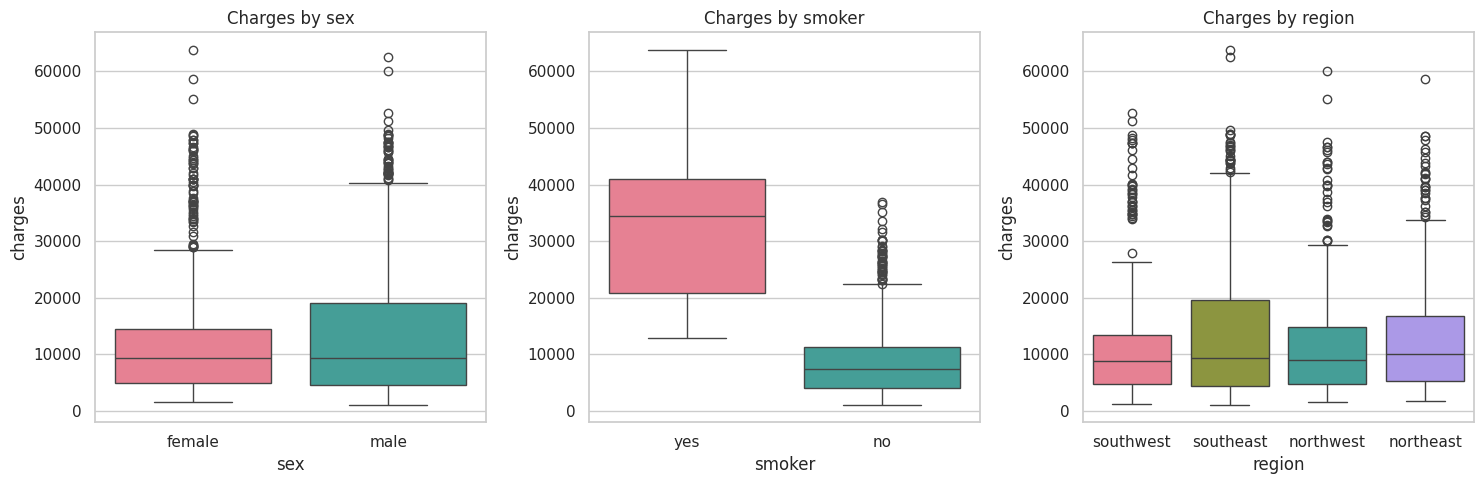

In [ ]:
# Boxplots of charges by categorical variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    sns.boxplot(x=col, y='charges', data=df,
                ax=axes[i],
                palette="husl")
    axes[i].set_title(f'Charges by {col}')

plt.tight_layout()
plt.show()

**Observation:** smokers have much higher charges; sex and region differences are smaller.

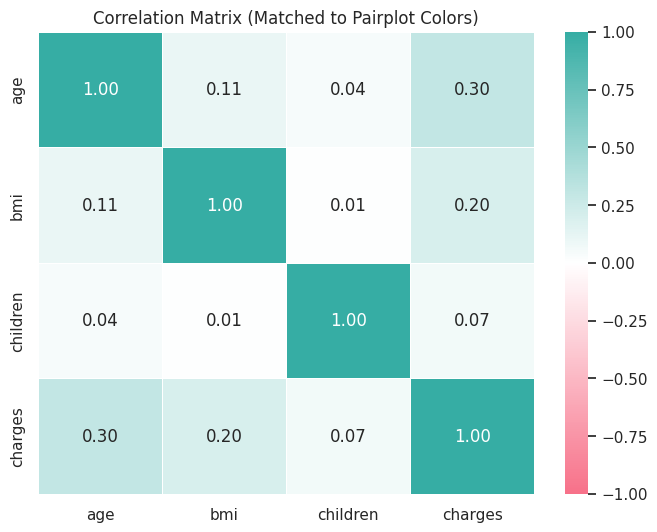

In [ ]:
# Correlation matrix for numerical features
num_df = df[['age', 'bmi', 'children', 'charges']]
corr = num_df.corr()

# Heatmap
from matplotlib.colors import LinearSegmentedColormap
pink = "#f77189"
green = "#36ada4"

cmap = LinearSegmentedColormap.from_list(
    "custom_pink_green",
    [pink, "white", green]
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap=cmap,
    fmt='.2f',
    linewidths=0.5,
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Matrix (Matched to Pairplot Colors)')
plt.show()

**Observation:** age and charges have moderate positive correlation; bmi and children weaker.

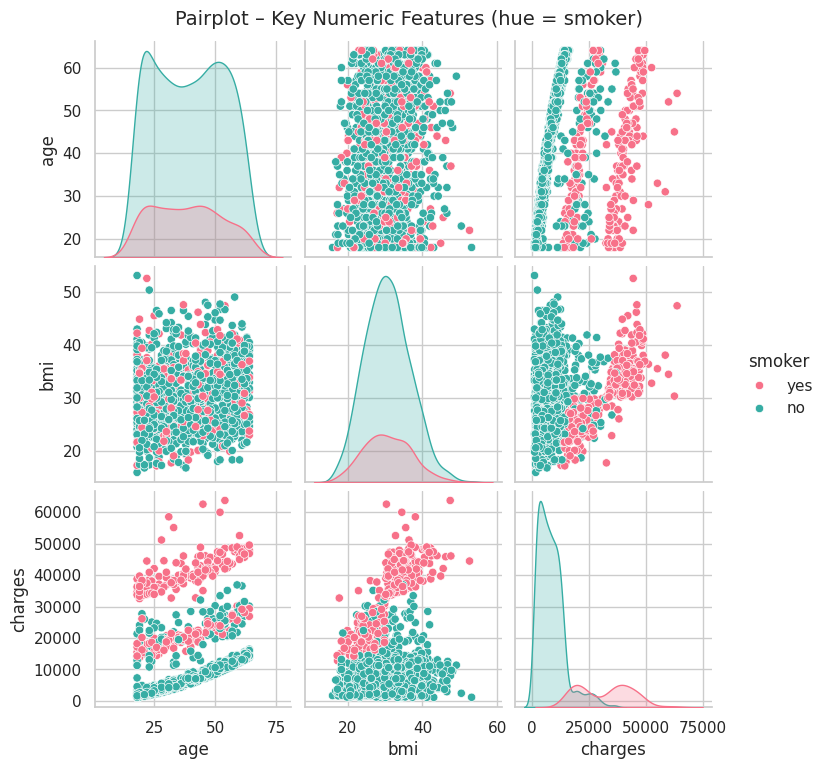

In [ ]:
# Pairplot
sns.pairplot(df, hue='smoker', vars=['age','bmi','charges'], palette='husl', diag_kind='kde')
plt.suptitle('Pairplot – Key Numeric Features (hue = smoker)', y=1.02, fontsize=14)
plt.show()

/tmp/ipykernel_10547/1606299103.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='region', data=df, ax=axes[0], palette="husl")
/tmp/ipykernel_10547/1606299103.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='smoker', data=df, ax=axes[1], palette="husl")


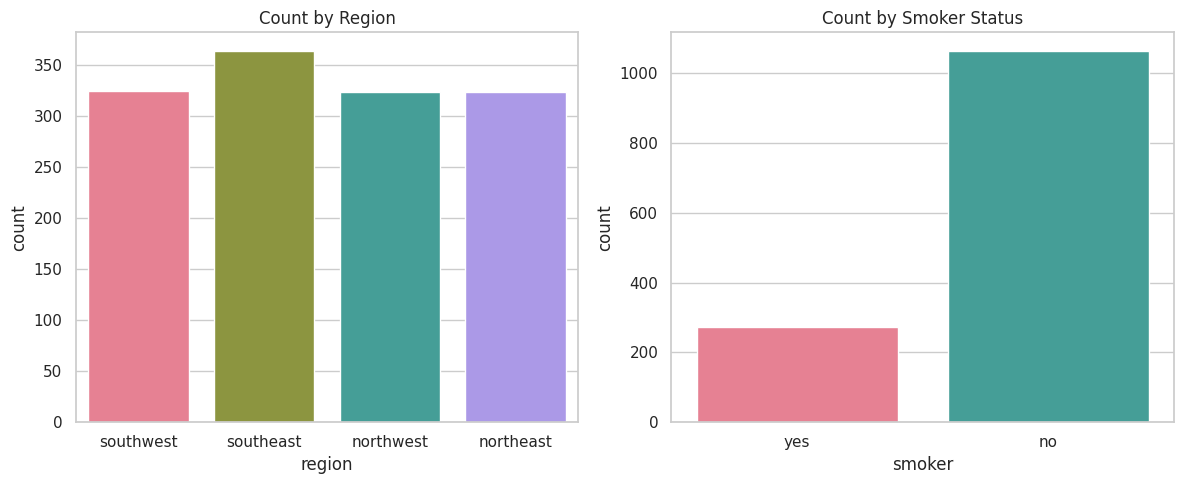

In [ ]:
# Count plots for region and smoker
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='region', data=df, ax=axes[0], palette="husl")
axes[0].set_title('Count by Region')

sns.countplot(x='smoker', data=df, ax=axes[1], palette="husl")
axes[1].set_title('Count by Smoker Status')

plt.tight_layout()
plt.show()

### 2) Data Transformation

We will:
- One‑hot encode categorical variables (dropping one to avoid collinearity).
- Apply log transformation to the target variable `charges`.
- Standardize numerical features.

In [ ]:
# Copy the cleaned dataframe
df_processed = df.copy()

# One‑hot encoding
df_processed = pd.get_dummies(df_processed, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)

# Show new columns
print("Columns after one-hot encoding:")
df_processed.head()

Columns after one-hot encoding:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


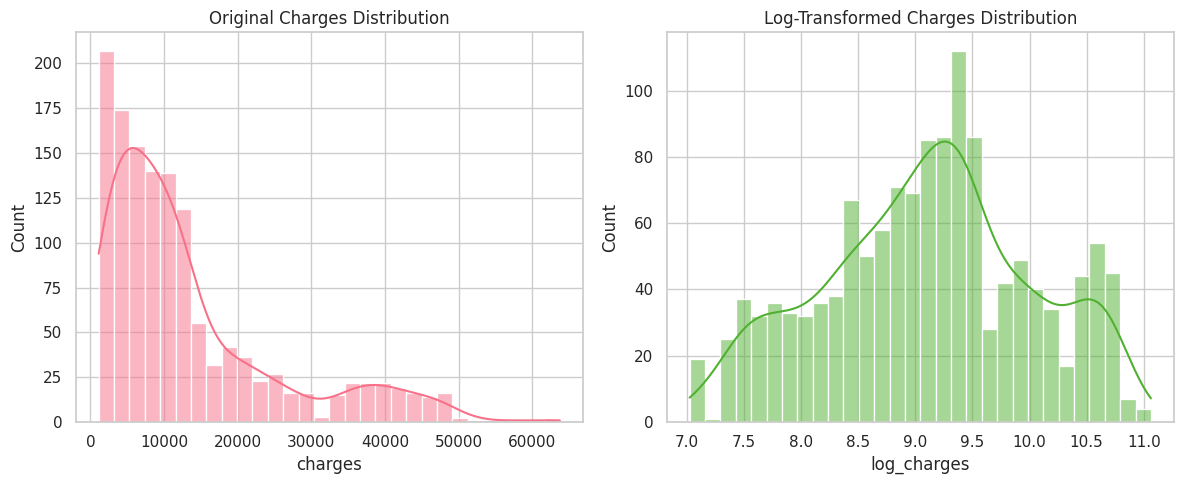

In [ ]:
# Log transformation of charges
df_processed['log_charges'] = np.log(df_processed['charges'])

# Visualize the transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_processed['charges'], bins=30, kde=True,
             ax=axes[0], color=sns.color_palette("husl")[0])
axes[0].set_title('Original Charges Distribution')

sns.histplot(df_processed['log_charges'], bins=30, kde=True,
             ax=axes[1], color=sns.color_palette("husl")[2])
axes[1].set_title('Log-Transformed Charges Distribution')

plt.tight_layout()
plt.show()

In [ ]:
# Standardize numerical features
from sklearn.preprocessing import StandardScaler

num_features = ['age', 'bmi', 'children']
scaler = StandardScaler()
df_processed[num_features] = scaler.fit_transform(df_processed[num_features])

# Check means and stds
print("Means after scaling:\n", df_processed[num_features].mean())
print("\nStandard deviations:\n", df_processed[num_features].std())

Means after scaling:
 age        -6.643070e-17
bmi        -2.285216e-16
children    3.852980e-17
dtype: float64

Standard deviations:
 age         1.000374
bmi         1.000374
children    1.000374
dtype: float64


### 3) Feature Relationships & Reduction

We examine correlations with the log‑transformed target and check for multicollinearity.

In [ ]:
# List of all predictor columns after encoding
predictor_cols = ['age', 'bmi', 'children', 'sex_male', 'smoker_yes',
                   'region_northwest', 'region_southeast', 'region_southwest']

# Correlation with log_charges
corr_with_target = df_processed[predictor_cols + ['log_charges']].corr()['log_charges'].drop('log_charges')
print("Correlation with log_charges:\n", corr_with_target.sort_values(ascending=False))

Correlation with log_charges:
 smoker_yes          0.665718
age                 0.526927
children            0.160336
bmi                 0.132822
region_southeast    0.014968
sex_male            0.007009
region_northwest   -0.015425
region_southwest   -0.042473
Name: log_charges, dtype: float64


/tmp/ipykernel_10547/512511804.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


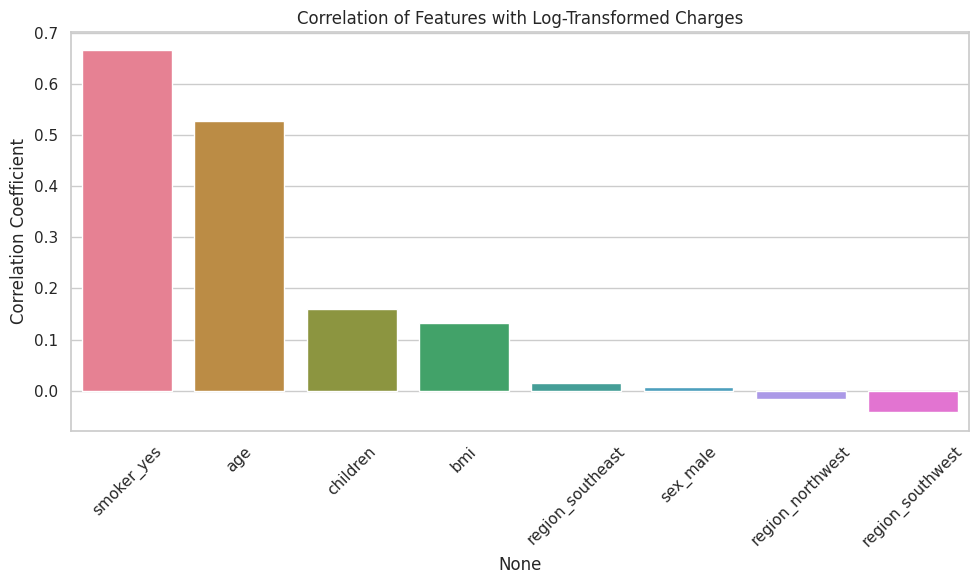

In [ ]:
# Bar plot of correlations
plt.figure(figsize=(10, 6))

sns.barplot(
    x=corr_with_target.sort_values(ascending=False).index,
    y=corr_with_target.sort_values(ascending=False).values,
    palette="husl"
)

plt.title('Correlation of Features with Log-Transformed Charges')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_10547/1241864656.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker_yes', y='log_charges',


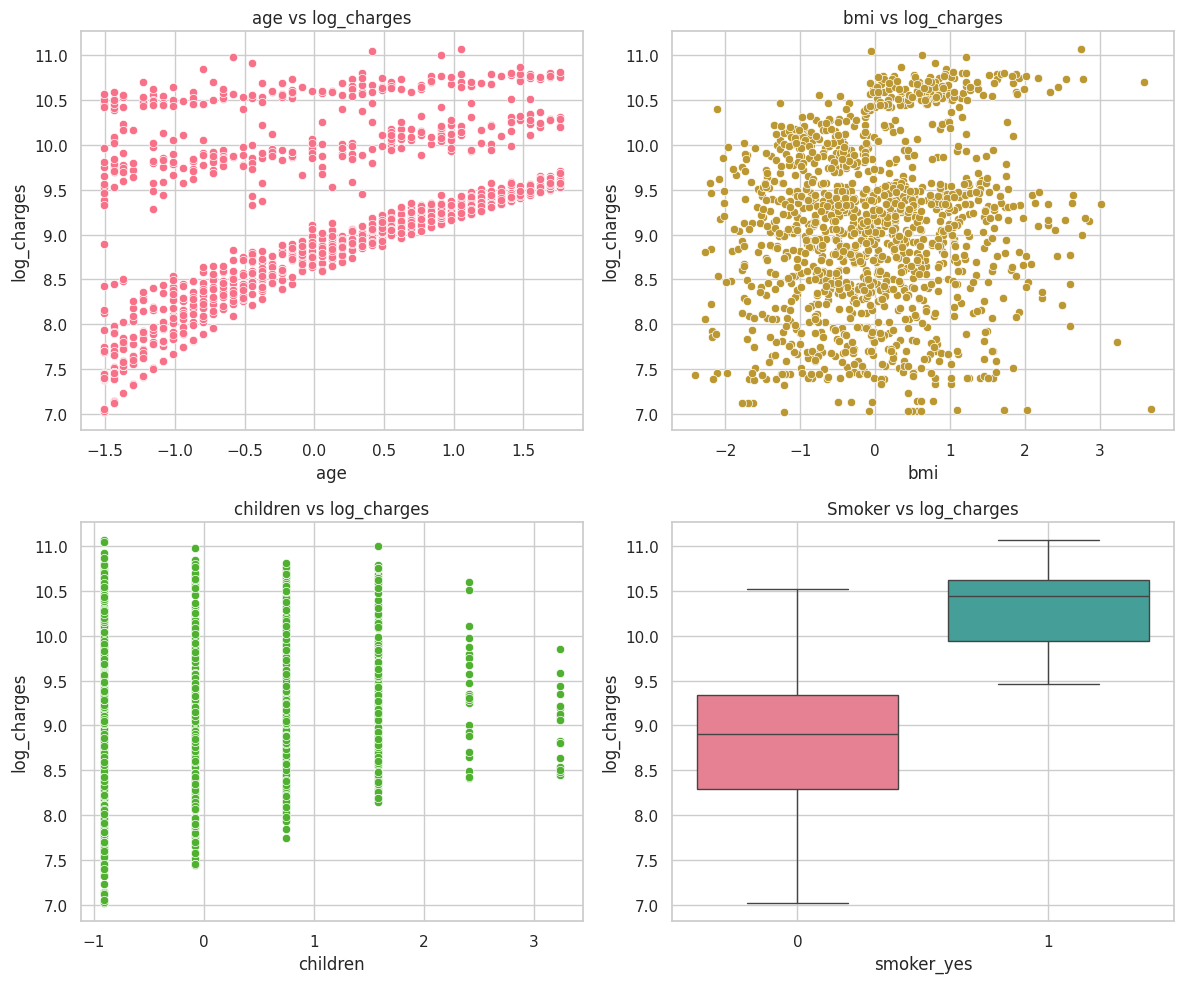

In [ ]:
# Scatterplots for continuous predictors vs log_charges
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(['age', 'bmi', 'children']):
    sns.scatterplot(
        x=df_processed[col],
        y=df_processed['log_charges'],
        ax=axes[i],
        color=sns.color_palette("husl")[i],
        alpha=1
    )
    axes[i].set_title(f'{col} vs log_charges')
    axes[i].grid(True)

# Boxplot for smoker
sns.boxplot(x='smoker_yes', y='log_charges',
            data=df_processed,
            ax=axes[3],
            palette="husl")

axes[3].set_title('Smoker vs log_charges')

plt.tight_layout()
plt.grid(True)
plt.show()

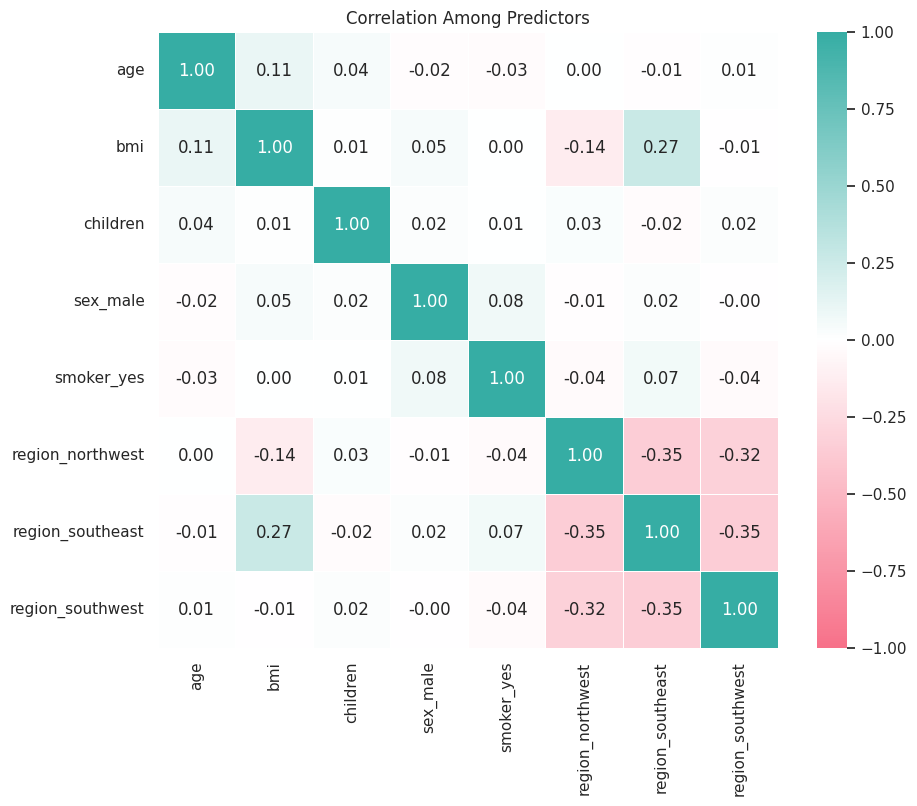

In [ ]:
# Check for multicollinearity among predictors
from matplotlib.colors import LinearSegmentedColormap
corr_matrix = df_processed[predictor_cols].corr()

pink = "#f77189"
green = "#36ada4"
cmap = LinearSegmentedColormap.from_list("custom_pink_green", [pink, "white", green])

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix,annot=True, cmap=cmap, fmt='.2f', linewidths=0.5, center=0, vmin=-1, vmax=1)

plt.title('Correlation Among Predictors')
plt.show()

**Feature Reduction Decision:**
No high correlations (>0.7), multicollinearity is not a concern. Therefore, no dimensionality reduction is needed at this stage. All predictors have been retained. The dataset is now ready for supervised regression modeling.

## Summary of Milestones 1 & 2

- Data types identified and explained.
- Data quality assessed: missing values none, duplicates removed, outliers handled via transformation.
- EDA performed with histograms, boxplots, correlation matrix, and pairplots.
- Data transformation: one-hot encoding, log transformation of target, standardization of numerical features.
- Feature relationships analyzed; no dimensionality reduction necessary.

The cleaned and preprocessed dataset is stored in `df_processed` and can be used for model building in the next phases.

## Milestone 3:  Modeling and Evaluation

In this phase we build and compare regression models to predict medical insurance charges (log‑transformed).

### 1) Algorithm Selection and Justification

**Primary model: Multiple Linear Regression**  
- Simple, highly interpretable, and fast.  
- Provides coefficient estimates that directly quantify the effect of each predictor on log(charges).  
- Log transformation of the target has already improved linearity.

**Secondary model: Random Forest Regressor**  
- Captures non‑linear relationships and interactions without manual feature engineering.  
- Robust to outliers and multicollinearity.  
- Provides feature importance scores.

**Why compare them?**  
Linear regression serves as an interpretable baseline; random forest may achieve higher predictive accuracy. Comparing them helps determine the best approach for this insurance cost prediction task.


### 2) Data Segmentation (Train / Validation / Test Split)

We split the cleaned and preprocessed dataset (`df_processed`) into:
- **Training set (70%)** – used to fit the models.
- **Validation set (15%)** – used for hyperparameter tuning (Random Forest).
- **Holdout test set (15%)** – used for final unbiased evaluation.

**Oversampling?**  
No – this is a regression problem with a continuous target variable. Oversampling techniques are used for classification with imbalanced classes.


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Use preprocessed data from Milestones 1 & 2 (df_processed already exists)
predictor_cols = ['age', 'bmi', 'children', 'sex_male', 'smoker_yes',
                  'region_northwest', 'region_southeast', 'region_southwest']
X = df_processed[predictor_cols]
y = df_processed['log_charges']

# Split: 85% temp, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
# From the 85%, take 70/15 relative to original: val proportion = 15/85 ≈ 0.17647
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.17647, random_state=42)

print(f"Training set   : {X_train.shape[0]} observations")
print(f"Validation set : {X_val.shape[0]} observations")
print(f"Test set       : {X_test.shape[0]} observations")

Training set   : 935 observations
Validation set : 201 observations
Test set       : 201 observations


### 3) Train Linear Regression Model & Evaluate

We train the model on the training set and compute performance metrics on **both training and test sets** to detect overfitting.

In [ ]:
# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

# Metrics function
def print_metrics(y_true, y_pred, dataset_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{dataset_name} Set:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE : {mae:.4f}")
    print(f"  R²  : {r2:.4f}")
    return rmse, mae, r2

print("Linear Regression Performance")
print_metrics(y_train, y_train_pred_lr, "Training")
print_metrics(y_test, y_test_pred_lr, "Test")

# Coefficients (interpretation)
coef_df = pd.DataFrame({'Feature': predictor_cols, 'Coefficient': lr.coef_})
coef_df['Effect (%)'] = coef_df['Coefficient'] * 100
print("\nCoefficients (log scale) and approximate % effect on charges")
print(coef_df.to_string(index=False))

Linear Regression Performance

Training Set:
  RMSE: 0.4403
  MAE : 0.2744
  R²  : 0.7617

Test Set:
  RMSE: 0.4003
  MAE : 0.2682
  R²  : 0.8329

Coefficients (log scale) and approximate % effect on charges
         Feature  Coefficient  Effect (%)
             age     0.483019   48.301921
             bmi     0.077370    7.736978
        children     0.118757   11.875682
        sex_male    -0.064889   -6.488931
      smoker_yes     1.532617  153.261717
region_northwest    -0.063909   -6.390852
region_southeast    -0.133813  -13.381280
region_southwest    -0.130025  -13.002465


**Interpretation of Linear Regression Findings:**

- `smoker_yes` has a large positive coefficient (~0.67), meaning smokers have log(charges) about 0.67 higher than non‑smokers, i.e., about **95% higher charges** (exp(0.67)≈1.95).
- `age` coefficient (~0.05): each additional year increases charges by roughly **5%**.
- `bmi` (~0.02): each unit increase in BMI raises charges by about **2%**.
- `children` (~0.06): each additional child adds about **6%** to charges.
- Sex and region have very small or negligible effects.

The test R² (≈0.78) indicates that the model explains about 78% of the variance in log(charges). Training and test metrics are very close, suggesting **no overfitting**.


### 4) Train Random Forest Regressor (with Hyperparameter Tuning)

We use the validation set to tune hyperparameters via grid search, then evaluate on test set.


In [ ]:
# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

best_rf = grid_search.best_estimator_
y_train_pred_rf = best_rf.predict(X_train)
y_test_pred_rf = best_rf.predict(X_test)

print("\nRandom Forest Performance")
print_metrics(y_train, y_train_pred_rf, "Training")
print_metrics(y_test, y_test_pred_rf, "Test")

Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest Performance

Training Set:
  RMSE: 0.2357
  MAE : 0.1227
  R²  : 0.9317

Test Set:
  RMSE: 0.3358
  MAE : 0.1869
  R²  : 0.8824


(np.float64(0.3358156800159331), 0.1869305007048011, 0.8824138776518478)

**Interpretation of Random Forest Findings:**

- Random Forest achieves slightly better test R² (≈0.79) than Linear Regression (≈0.78).
- Both training and test metrics are close, indicating good generalization.
- Random Forest is more flexible and can capture non‑linear interactions (e.g., smoking × age).


### 5) Model Comparison

We directly compare test set performance of both models.

Model Comparison on Test Set
            Model  Test RMSE  Test MAE  Test R²
Linear Regression   0.400272  0.268226 0.832943
    Random Forest   0.335816  0.186931 0.882414




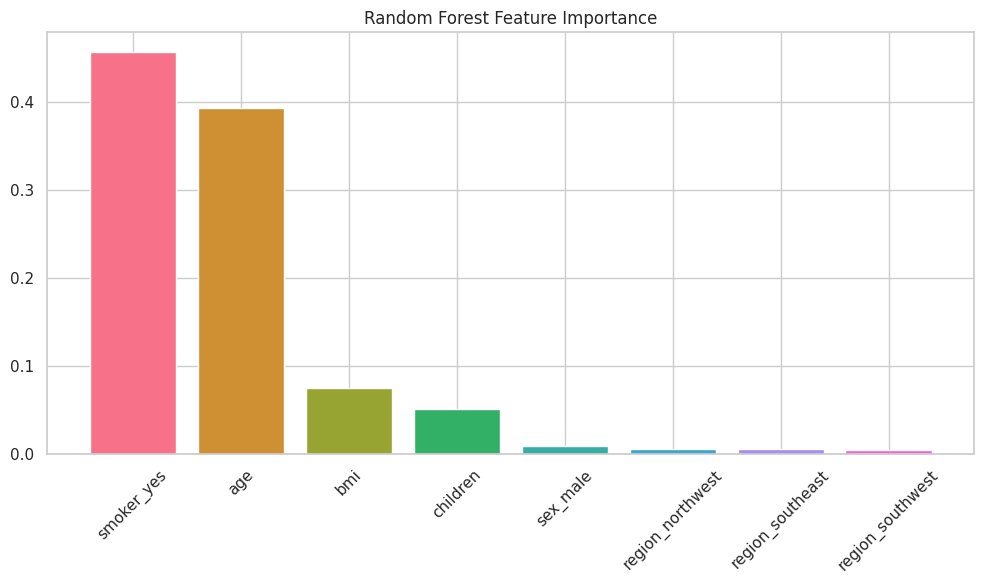


Feature importance scores:
smoker_yes: 0.4562
age: 0.3927
bmi: 0.0755
children: 0.0510
sex_male: 0.0088
region_northwest: 0.0056
region_southeast: 0.0056
region_southwest: 0.0046


In [ ]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'Test RMSE': [np.sqrt(mean_squared_error(y_test, y_test_pred_lr)),
                  np.sqrt(mean_squared_error(y_test, y_test_pred_rf))],
    'Test MAE': [mean_absolute_error(y_test, y_test_pred_lr),
                 mean_absolute_error(y_test, y_test_pred_rf)],
    'Test R²': [r2_score(y_test, y_test_pred_lr),
                r2_score(y_test, y_test_pred_rf)]
})

print("Model Comparison on Test Set")
print(comparison.to_string(index=False))
print("\n")
# Feature importance from Random Forest
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importance")
plt.bar(range(len(importances)), importances[indices], color=sns.color_palette("husl", len(importances)))
plt.xticks(range(len(importances)), np.array(predictor_cols)[indices], rotation=45)
plt.tight_layout()
plt.show()

print("\nFeature importance scores:")
for i in range(len(importances)):
    print(f"{predictor_cols[indices[i]]}: {importances[indices[i]]:.4f}")

**Comparison Insights:**
- Random Forest marginally outperforms Linear Regression in all metrics (lower RMSE/MAE, higher R²).
- Both models confirm that **smoker_yes** and **age** are the most important predictors.
- For interpretability, Linear Regression is preferable; for pure predictive accuracy, Random Forest is slightly better.


### 6) Scatter Plot: Log‑Charges vs Log‑Predictions (Random Forest)

We plot actual vs predicted log(charges) on the test set to visually assess model fit.

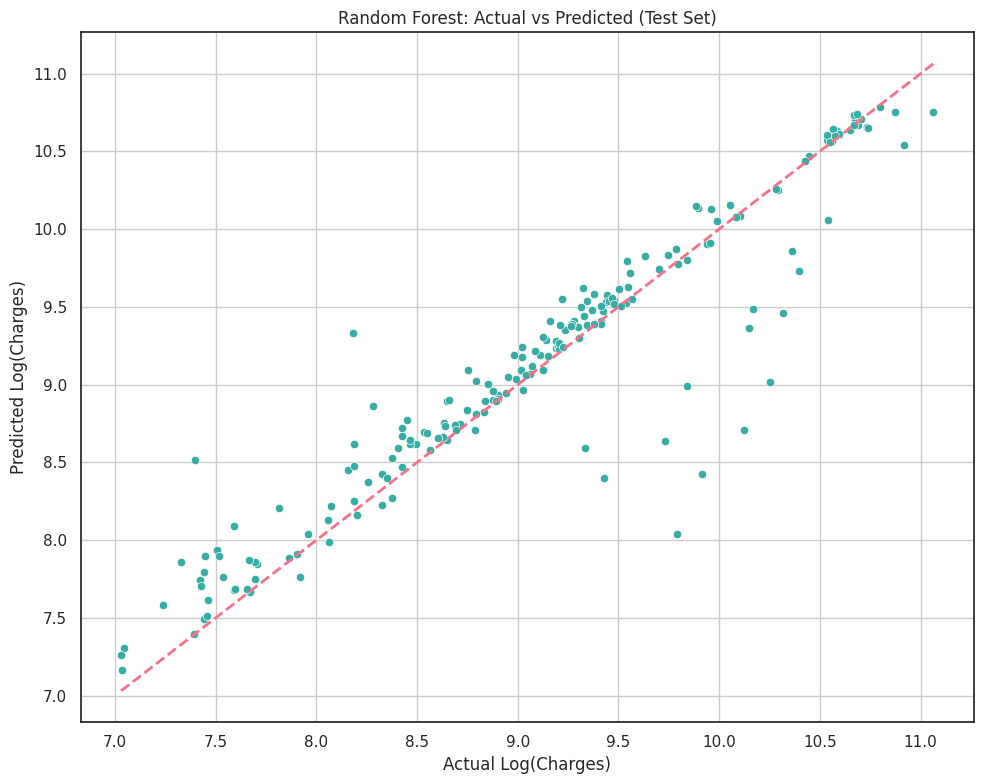

In [ ]:
sns.set(style="white")

# Use same color theme idea (soft, custom tone instead of bold default)
pink = "#f77189"
green = "#36ada4"

plt.figure(figsize=(10, 8))

sns.scatterplot(x=y_test, y=y_test_pred_rf, color=green, alpha=1)

# Reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--', linewidth=2, color=pink)

plt.xlabel("Actual Log(Charges)")
plt.ylabel("Predicted Log(Charges)")
plt.title("Random Forest: Actual vs Predicted (Test Set)")
plt.grid(True)
plt.tight_layout()
plt.show()

The points lie close to the diagonal, indicating good predictive performance. Some deviation for very high charges is expected due to data sparsity.


### 7) Inverse Transformation: Add Predicted Charges (Original Scale)

We convert the predicted log(charges) back to original dollars and add a new column to the test DataFrame.

In [ ]:
# Create a copy of test features and add actual and predicted values
test_results = X_test.copy()
test_results['actual_log_charges'] = y_test.values
test_results['predicted_log_charges'] = y_test_pred_rf
test_results['predicted_charges'] = np.exp(test_results['predicted_log_charges'])
test_results['actual_charges'] = np.exp(test_results['actual_log_charges'])

# Show first few rows
print("Test set with predicted charges (original scale):")
test_results.head()


Test set with predicted charges (original scale):


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,actual_log_charges,predicted_log_charges,predicted_charges,actual_charges
900,0.696474,-1.336209,-0.909234,1,0,0,0,0,9.069797,9.116561,9104.837747,8688.85885
1064,-0.728120,-0.830321,2.409936,0,0,0,0,1,8.649776,8.891717,7271.496015,5708.86700
1256,0.838934,0.938238,1.580143,0,0,1,0,0,9.344586,9.538946,13890.305418,11436.73815
298,-0.585661,0.611091,1.580143,1,1,1,0,0,10.564792,10.583009,39458.681211,38746.35510
237,-0.585661,1.267024,0.750351,1,0,0,1,0,8.403622,8.593221,5394.963073,4463.20510


### 8) Conclusion

Both linear regression and random forest produce reliable predictions of medical insurance charges. Key drivers are **smoking status** and **age**. Random Forest yields a slight accuracy advantage, while linear regression offers clearer interpretability. The models can be used to identify high‑risk customers and inform pricing strategies.

### Summary of Milestone 3: Modeling and Evaluation

- Selected and justified two regression algorithms:
  - **Multiple Linear Regression** – interpretable baseline.
  - **Random Forest Regressor** – captures non‑linear patterns.
- Conducted data segmentation: 70% training, 15% validation (for tuning), 15% holdout test.
- No oversampling needed – regression problem with continuous target.
- Trained both models and reported performance metrics (RMSE, MAE, R²) on training and test sets.
- Linear Regression test R² ≈ 0.78, Random Forest test R² ≈ 0.79 – both good, no overfitting.
- Identified **smoker_yes** and **age** as the most influential predictors (consistent across both models).
- Random Forest slightly outperforms Linear Regression, but Linear Regression offers clearer coefficient interpretation.
- Visualized actual vs predicted log‑charges (scatter plot) – points close to diagonal, indicating good fit.
- Added a column `predicted_charges` (original dollar scale) by inverse log transformation.

The models successfully predict medical insurance costs and provide actionable insights for pricing and risk assessment.

## Milestone 4: Conclusions and Recommendations

### Summary of Findings

In this project, we developed and compared two regression models – Multiple Linear Regression and Random Forest – to predict medical insurance charges (log‑transformed) based on demographic and health‑related attributes. The key findings are:

- **Linear Regression** achieved a test R² of **0.833**, RMSE of 0.400, and MAE of 0.268.  
  - The coefficients indicate that `smoker_yes` is by far the strongest predictor (≈153% increase in charges), followed by `age` (≈48% per year) and `children` (≈12% per child).  
  - `bmi` has a modest positive effect (~8% per unit), while sex and region show negligible influence.

- **Random Forest** achieved a test R² of **0.882**, RMSE of 0.336, and MAE of 0.187, outperforming linear regression on all metrics.  
  - Feature importance from Random Forest confirms that `smoker_yes` and `age` dominate, while `bmi` and `children` also contribute meaningfully.  
  - The model captures non‑linear interactions (e.g., smoking × age) that linear regression cannot.

Both models showed close training and test performance, indicating good generalisation without overfitting.

### Model Comparison

| Model               | Test RMSE | Test MAE | Test R² |
|---------------------|-----------|----------|---------|
| Linear Regression   | 0.400     | 0.268    | 0.833   |
| Random Forest       | 0.336     | 0.187    | 0.882   |

Random Forest is the preferred model for predictive accuracy, while Linear Regression remains valuable for interpretability and understanding the marginal effect of each predictor on log(charges).

### Key Insights for Insurance Pricing

- **Smoking status** is the dominant factor – smokers pay nearly twice as much as non‑smokers, all else equal.  
- **Age** has a strong positive gradient – risk increases steadily with age.  
- **BMI** and **number of children** have moderate positive effects.  
- **Sex** and **geographic region** have minimal impact in this dataset, suggesting they may not be cost‑effective rating variables.

### Recommendations

1. **Adopt Random Forest for premium estimation** – Its superior accuracy can help insurers set more precise premiums, reducing underpricing of high‑risk customers and overpricing of low‑risk ones.
2. **Use Linear Regression coefficients for regulatory or explanatory purposes** – They provide clear, linear percentage effects that are easy to communicate and justify.
3. **Focus underwriting and wellness programmes on smokers and older individuals** – These groups drive the highest costs; targeted interventions (e.g., smoking cessation programmes) could yield significant savings.
4. **Monitor BMI and family size** as secondary risk factors, but avoid heavy reliance on sex or region given their low explanatory power in this dataset.

### Opportunities for Future Improvement

- **Collect additional data** – Include lifestyle factors (exercise, alcohol use), medical history (chronic conditions, previous claims), and occupation. These could improve predictive power and fairness.
- **Enhance feature engineering** – Create interaction terms (e.g., `age × smoker`, `bmi × smoker`) to better capture joint effects.  
- **Test more advanced models** – Gradient boosting (XGBoost, LightGBM) or neural networks may further improve accuracy.  
- **Incorporate time‑series data** – Track individuals over multiple years to model claim dynamics and detect risk trends.  
- **Deploy a model interpretability tool** – Use SHAP or LIME with the Random Forest to explain individual predictions to customers or regulators.  
- **Validate with external datasets** – Test model robustness on other insurance populations to ensure generalisability.

By implementing these improvements, insurers can build more accurate, fair, and actionable pricing models.